# part 1

In [1]:
# data thử
X_test = [
    [1, 1.2, 3.5],
    [1, 2.3, 4.1],
    [1, 3.1, 5.2],
    [1, 4.5, 6.8],
    [1, 5.2, 7.9]
]
y_test = [8.5, 11.2, 13.5, 17.0, 19.5]

### 1. Hàm OLS Fit 

Để tìm ước lượng bình phương tối thiểu $\hat{\beta}$, ta giải phương trình chuẩn (normal equation):$$\mathbf{X}^T\mathbf{X}\hat{\beta} = \mathbf{X}^T\mathbf{y} \implies \hat{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$Phương sai sai số được ước lượng qua:$$\hat{\sigma}^2 = \frac{RSS}{n - p} = \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{n - p}$$Trong đó $n$ là số quan sát và $p$ là số biến độc lập (bao gồm cả intercept).

In [2]:
from ols_implementation import (ols_fit)

# 3. Tính OLS
beta, sigma2 = ols_fit(X_test, y_test)
print(f"1. Beta hat: {beta}")
print(f"2. Sigma hat square: {sigma2}")

1. Beta hat: [3.8469793986640752, 1.9576141425387732, 0.6747633630299674]
2. Sigma hat square: 0.04817545935412006


### 3. Hat Matrix
Ma trận Hat (Projection Matrix) được định nghĩa là ma trận chiếu vector $\mathbf{y}$ lên không gian cột của $\mathbf{X}$:$$\mathbf{H} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$$Tính chất quan trọng nhất của ma trận này là tính Idempotent:$$\mathbf{H} \times \mathbf{H} = \mathbf{H}$$

In [3]:
from ols_implementation import (hat_matrix)
from tabulate import tabulate

# 4. Tính y_hat (dùng list comprehension)
p = len(X_test[0])
y_hat = [sum(X_test[i][j] * beta[j] for j in range(p)) for i in range(len(X_test))]

# 5. Kiểm tra Hat Matrix
H, is_idempotent = hat_matrix(X_test)
print(f"2. Hat Matrix:\n{tabulate(H, tablefmt="fancy_grid")}")
print(f"   Hat Matrix Idempotent: {is_idempotent}")


2. Hat Matrix:
╒════════════╤════════════╤═══════════╤═══════════╤════════════╕
│  0.961901  │  0.0204621 │ 0.093917  │ -0.148817 │  0.0725362 │
├────────────┼────────────┼───────────┼───────────┼────────────┤
│  0.0204621 │  0.666759  │ 0.356208  │  0.195017 │ -0.238447  │
├────────────┼────────────┼───────────┼───────────┼────────────┤
│  0.093917  │  0.356208  │ 0.255331  │  0.221617 │  0.0729259 │
├────────────┼────────────┼───────────┼───────────┼────────────┤
│ -0.148817  │  0.195017  │ 0.221617  │  0.377603 │  0.35458   │
├────────────┼────────────┼───────────┼───────────┼────────────┤
│  0.0725362 │ -0.238447  │ 0.0729259 │  0.35458  │  0.738405  │
╘════════════╧════════════╧═══════════╧═══════════╧════════════╛
   Hat Matrix Idempotent: True


### 4. Model Metrics

Các chỉ số đánh giá mô hình:

**RSS (Residual Sum of Squares):**
$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**TSS (Total Sum of Squares):**
$$TSS = \sum_{i=1}^{n} (y_i - \bar{y})^2$$

**Hệ số xác định ($R^2$):**
$$R^2 = 1 - \frac{RSS}{TSS}$$

**Thống kê F ($F$-statistic):**
$$F = \frac{(TSS - RSS) / (p - 1)}{RSS / (n - p)}$$

In [4]:
from ols_implementation import (model_metrics)


# 6. Model Metrics
metrics = model_metrics(y_test, y_hat, p=p)

print(metrics)
print(f"3. RSS: {metrics['RSS']:.4f}, TSS: {metrics['TSS']}, R2: {metrics['R2']:.4f}, Adj_R2: {metrics['Adj_R2']}, F: {metrics['F']:.4f}")


{'RSS': 0.09635091870824011, 'TSS': 77.572, 'R2': 0.9987579162750961, 'Adj_R2': 0.9975158325501923, 'F': 804.098706270726}
3. RSS: 0.0964, TSS: 77.572, R2: 0.9988, Adj_R2: 0.9975158325501923, F: 804.0987


### 5. Coefficient Inference
Ma trận hiệp phương sai của các hệ số ước lượng:$$Var(\hat{\beta}) = \hat{\sigma}^2 (\mathbf{X}^T\mathbf{X})^{-1}$$Standard Error (SE) của hệ số thứ $j$ là căn bậc hai của phần tử đường chéo thứ $j$ của ma trận $Var(\hat{\beta})$.Giá trị kiểm định $t$:$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$

In [5]:
from ols_implementation import (coef_inference)



# 7. Coef Inference
se, t_stats, p_values, confidence_intervals = coef_inference(X_test, y_test, beta, sigma2)

print(f"4. standard error: {se}\n")
print(f"t-statistic: {t_stats}\n")
print(f"p-value: {p_values}\n")
print(f"95% confidence interval: {confidence_intervals}")

4. standard error: [0.8085919355383487, 0.4757367035245466, 0.41940047272581343]

t-statistic: [4.757627710079513, 4.1149108909099885, 1.6088760192483131]

p-value: [0.04145174083104042, 0.054293121016140145, 0.2489167789009179]

95% confidence interval: [(0.36789171314460045, 7.32606708418355), (-0.08931414605455545, 4.004542431132101), (-1.1297698703987777, 2.4792965964587124)]


### 6. VIF (Variance Inflation Factor)
VIF đo lường mức độ đa cộng tuyến của biến thứ $j$:$$VIF_j = \frac{1}{1 - R_j^2}$$Trong đó $R_j^2$ là hệ số xác định khi hồi quy biến $X_j$ lên các biến độc lập còn lại.

In [6]:
from ols_implementation import (vif)
# 5. VIF
vif_vals = vif(X_test)
print(f"5. VIF: {vif_vals}")

5. VIF: [49.29078507795085, 49.29078507795085]


# Bài 6 — `ridge_fit(X, y, lam)`: Ridge Regression + Ridge Trace

## (a) CÔNG THỨC TOÁN HỌC

Bài toán:

$$
\min_{\beta} \; \|y - X\beta\|^2 + \lambda \|\beta\|^2,
\qquad \lambda \ge 0
$$

Lấy đạo hàm theo \(\beta\) và cho bằng 0:

$$
-2X^T(y - X\beta) + 2\lambda\beta = 0
$$

$$
(X^T X + \lambda I)\beta = X^T y
$$

Suy ra:

$$
\hat{\beta}_{\text{ridge}}(\lambda)
=
(X^T X + \lambda I)^{-1} X^T y
$$

### Tính chất

- Khi ($\lambda = 0$):

$$
\hat{\beta}_{\text{ridge}}
=
\hat{\beta}_{\text{OLS}}
$$

- Khi $(\lambda$) tăng lớn:

$$
\hat{\beta}_{\text{ridge}} \to 0
$$

Ridge sẽ co các hệ số về gần 0 để giảm phương sai mô hình.

- Ma trận:

$$
X^T X + \lambda I
$$

luôn khả nghịch khi:

$$
\lambda > 0
$$

Do đó Ridge vẫn hoạt động ngay cả khi dữ liệu bị đa cộng tuyến mạnh hoặc $(X^{T} X)$ suy biến.

### Ridge Trace

Ridge trace là đồ thị biểu diễn từng hệ số:

$$
\hat{\beta}_j(\lambda)
$$

theo:

$$
\log(\lambda)
$$

Khi $(\lambda)$ tăng, các hệ số thường dần ổn định và tiến gần về 0.


[[-0.14409032957792836, -0.1729036003315193, -0.1463166468092816, -0.15886392582954204, -0.16104873063038155], [-1.4973534143409575, 0.33231834406771527, -1.5027001639109008, 0.3279791703848114, -0.580199839402604], [0.23229773690672087, 1.163558686599143, 0.24543046704269425, 1.1657688301480196, 0.6831617797060355], [-1.014662367487717, 0.24634219521120196, -0.9884407509436361, 0.24717533248926965, -0.3862865520136733], [0.5317762204008692, -1.453545298008678, 0.525530674057978, -1.4437380473568076, -0.44341645109631544], [-0.2406296726551354, 0.3765998586879102, -0.2356654036685671, 0.39224639486198304, 0.04572064873142394], [0.5682506875853858, -1.5145203917251397, 0.5158517791410088, -1.5266582062891298, -0.49145105299679687], [0.8760122430564063, 0.664265899612895, 0.8516307482304925, 0.681213128079855, 0.7500950148498037], [-0.08624384633628418, -0.29389977795653216, -0.08395544918706575, -0.27752705172565684, -0.17730353633055929], [0.3498851018692087, 0.6499480978062986, 0.3594

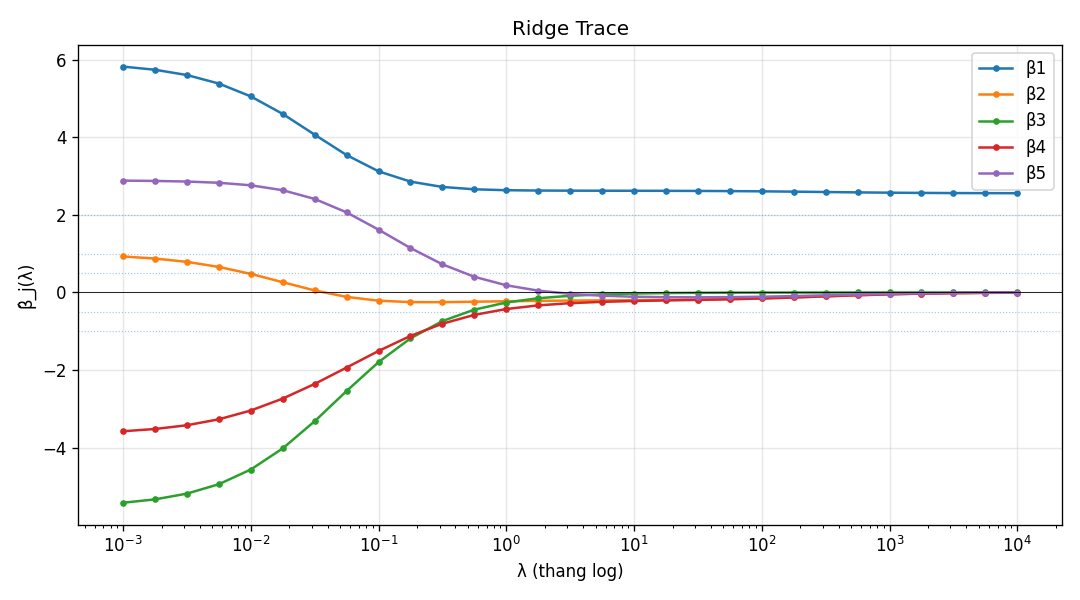


--- (d) Kiểm chứng với sklearn.Ridge ---
       λ |   sai khác max
----------------------------
   0.010 |      9.555e-01
   1.000 |      1.514e+00
  10.000 |      1.570e+00
 100.000 |      1.807e+00


In [7]:
from ridge_lasso import (ridge_fit, ridge_trace, simulate_collinear, simulate_collinear, center, plot_ridge_trace, verify_with_sklearn, standardize_columns)

# ============================================================
# Chạy thử
# ============================================================
# (c) Sinh dữ liệu
X, y, true_beta = simulate_collinear(n=120, seed=42)
print(X)
X_std, _, _ = standardize_columns(X)
y_c, _ = center(y)

print("β thật :", [round(b, 3) for b in true_beta])
print()
print(f"{'λ':>8} | β̂_ridge")
print("-" * 60)
for lam in [0.0, 0.1, 1.0, 10.0, 100.0, 1000.0]:
    beta = ridge_fit(X_std, y_c, lam)
    print(f"{lam:>8.2f} | {[round(b, 4) for b in beta]}")

# Ridge trace trên lưới log
lam_grid = [10 ** (i / 4) for i in range(-12, 17)]   # ~ 10^-3 → 10^4
traces = ridge_trace(X_std, y_c, lam_grid)
plot_ridge_trace(lam_grid, traces, true_beta=true_beta)

# (d) Kiểm chứng
verify_with_sklearn(X_std, y_c, [0.01, 1.0, 10.0, 100.0])

# Bài 7 — `residual_plots(X, y, beta_hat)`: 4 biểu đồ phân tích phần dư

## (a) CÔNG THỨC TOÁN HỌC

### Các đại lượng

$$
e_i = y_i - x_i^T \hat{\beta}
$$

- Phần dư thô

$$
\hat{y}_i = x_i^T \hat{\beta}
$$

- Giá trị fitted

$$
H = X (X^T X)^{-1} X^T
$$

- Hat matrix

$$
h_i = H_{ii}
$$

- Leverage (phần tử đường chéo của \(H\))

$$
\hat{\sigma}^2 = \frac{RSS}{n - p}
$$

- MSE đã hiệu chỉnh theo số bậc tự do

$$
r_i = \frac{e_i}{\hat{\sigma}\sqrt{1-h_i}}
$$

- Phần dư chuẩn hóa

$$
D_i = \left(\frac{r_i^2}{p}\right)\frac{h_i}{1-h_i}
$$

- Cook's distance

---

## Bốn biểu đồ cổ điển (`plot.lm` trong R)

### 1. Residuals vs Fitted

Kiểm tra:

- Giả định tuyến tính
- Phương sai không đổi (homoscedasticity)

---

### 2. Normal Q–Q

Kiểm tra:

- Phần dư có phân phối chuẩn hay không

Trục hoành:

$$
\Phi^{-1}\left(\frac{i-0.5}{n}\right)
$$

- Quantile lý thuyết của phân phối chuẩn

---

### 3. Scale–Location

Biểu diễn:

$$
\sqrt{|r_i|}
\quad \text{vs} \quad
\hat{y}_i
$$

Mục đích:

- Phát hiện heteroscedasticity

---

### 4. Residuals vs Leverage

Mục đích:

- Phát hiện các điểm có ảnh hưởng mạnh (influential points)
- Thường hiển thị kèm Cook’s distance

β thật : [2.0, -1.5, 0.8]
β̂      : [2.2692, -0.5291, 1.6581]
σ̂²     : 6.2905
[OK] Đã lưu residual_plots.png


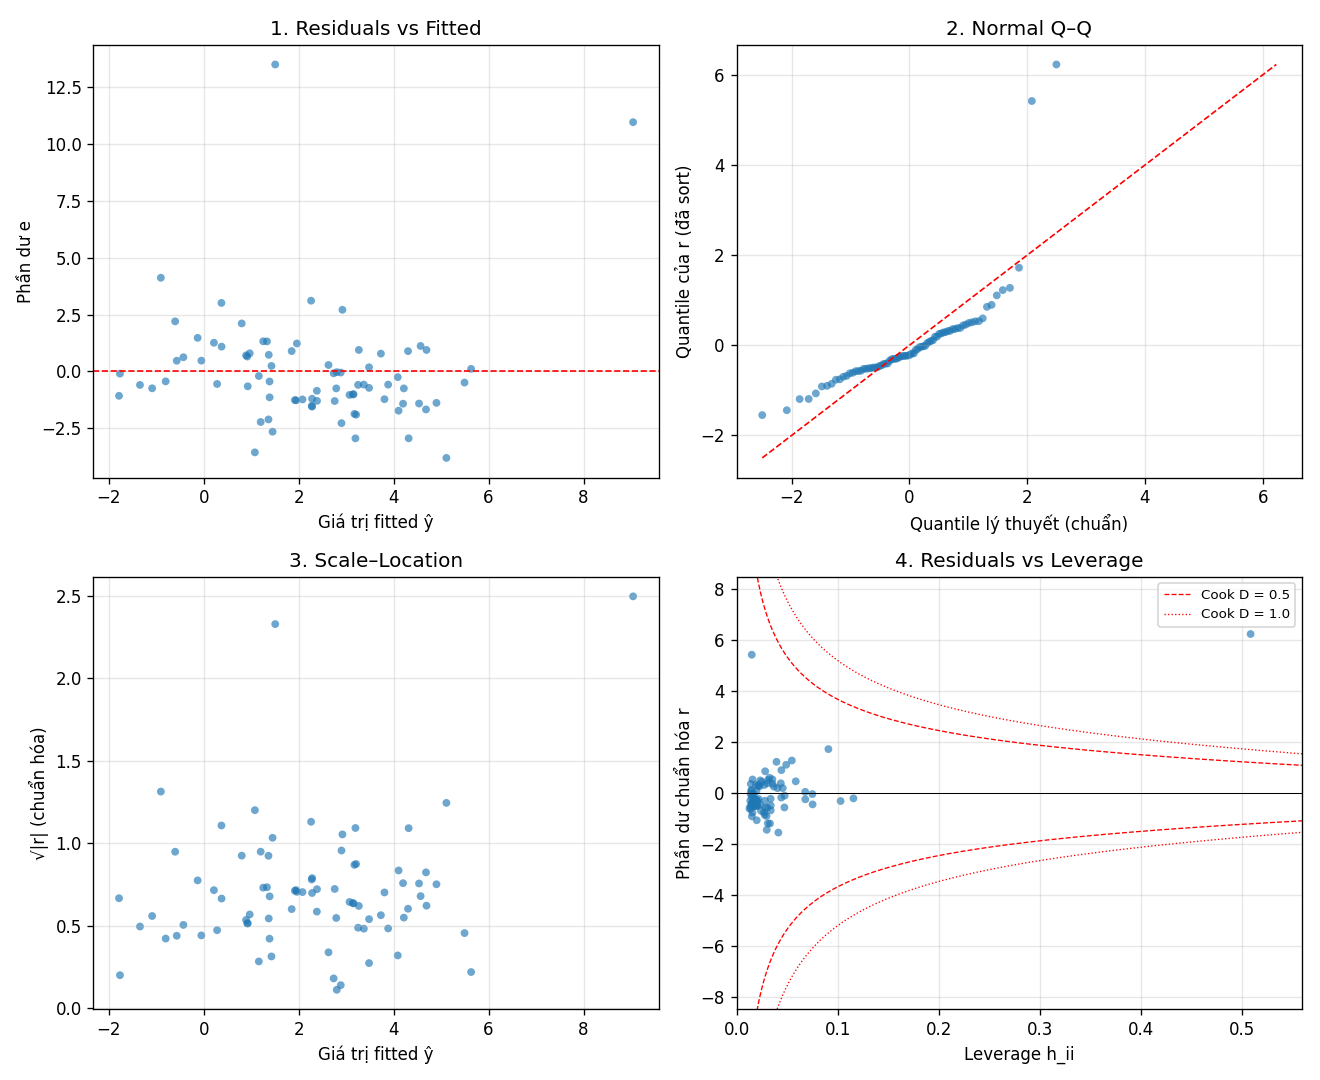


Một vài chẩn đoán:
  max leverage     = 0.5086
  Cook's D lớn nhất = 13.3989

--- (d) Kiểm chứng leverage & Cook's với statsmodels ---
max |h_ii   - h_sm|     = 1.110e-16
max |Cook_i - Cook_sm|  = 2.776e-17


In [8]:
from linalg_utils import (
    shape, transpose, matmul, matvec, inv
)
from ols_implementation import (hat_matrix, ols_fit)

from residual_analysis import (simulate_with_outliers, residual_plots, verify_with_statsmodels)


X, y, true_beta = simulate_with_outliers()
beta_hat, sigma2 = ols_fit(X, y)
print("β thật :", true_beta)
print("β̂      :", [round(b, 4) for b in beta_hat])
print("σ̂²     :", round(sigma2, 4))

result = residual_plots(X, y, beta_hat)
print("\nMột vài chẩn đoán:")
print(f"  max leverage     = {max(result['leverage']):.4f}")
print(f"  Cook's D lớn nhất = {max(result['cooks']):.4f}")

verify_with_statsmodels(X, y, result)

# Bài 8 — `kfold_cv(X, y, k)`: k-fold cross-validation

## (a) CÔNG THỨC TOÁN HỌC

Chia tập dữ liệu:

$$
D = \{(x_i, y_i)\}_{i=1}^{n}
$$

thành $(k)$ phần rời nhau xấp xỉ bằng nhau:

$$
D = D_1 \cup D_2 \cup \dots \cup D_k
$$

Với mỗi fold $(j = 1..k)$:

- Tập train:

$$
D_{\text{train}}^{(j)} = D \setminus D_j
$$

- Huấn luyện OLS trên $(D_{\text{train}}^{(j)})$:

$$
\hat{\beta}^{(j)}
=
(X_{\text{train}}^T X_{\text{train}})^{-1}
X_{\text{train}}^T y_{\text{train}}
$$

- Đánh giá trên $(D_j)$:

$$
\text{MSE}_j
=
\frac{1}{|D_j|}
\sum_{i \in D_j}
(y_i - x_i^T \hat{\beta}^{(j)})^2
$$

## CV score (Mean Squared Prediction Error)

$$
CV(k)
=
\frac{1}{k}
\sum_{j=1}^{k}
\text{MSE}_j
$$

In [9]:
from cross_validation import (_shuffle_indices, _split_into_folds, kfold_cv)
import random

from cross_validation import (simulate_regression, verify_with_sklearn)


X, y, true_beta = simulate_regression(n=200, p=4, sigma=1.0, seed=0)
print("β thật:", true_beta)

for k in [5, 10]:
    out = kfold_cv(X, y, k=k, seed=42)
    print(f"\n=== k = {k} ===")
    print(f"CV (từ đầu) = {out['cv_score']:.8f}")
    print(f"MSE từng fold: {[round(m, 4) for m in out['fold_mses']]}")

    sk = verify_with_sklearn(X, y, k=k, seed=42)
    if sk is not None:
        sk_cv, sk_mses = sk
        diff = abs(out["cv_score"] - sk_cv)
        print(f"|CV(của ta) - CV(sklearn)| = {diff:.3e}")
        max_fold_diff = max(abs(out["fold_mses"][i] - sk_mses[i])
                            for i in range(k))
        print(f"Sai khác max MSE từng fold = {max_fold_diff:.3e}")

β thật: [2.0, -1.5, 0.8, 0.3]

=== k = 5 ===
CV (từ đầu) = 1.16099551
MSE từng fold: [1.0771, 1.1387, 1.2422, 1.6515, 0.6955]

--- (d) Kiểm chứng với sklearn (cùng phân chia fold) ---
CV sklearn = 1.16099551
|CV(của ta) - CV(sklearn)| = 6.661e-16
Sai khác max MSE từng fold = 8.882e-16

=== k = 10 ===
CV (từ đầu) = 1.17208744
MSE từng fold: [0.9452, 1.2904, 0.9306, 1.2932, 1.0763, 1.3823, 2.4546, 0.9254, 0.812, 0.6109]

--- (d) Kiểm chứng với sklearn (cùng phân chia fold) ---
CV sklearn = 1.17208744
|CV(của ta) - CV(sklearn)| = 2.220e-16
Sai khác max MSE từng fold = 1.776e-15


# Bài 9 — Mô phỏng Monte Carlo: Định lý Gauss–Markov

---

## (a) Phát biểu và công thức

Xét mô hình hồi quy tuyến tính:

$$
y = X\beta + \varepsilon
$$

với:

$$
E[\varepsilon] = 0
$$

$$
\operatorname{Var}(\varepsilon) = \sigma^2 I_n
$$

Điều này có nghĩa:

- Sai số có kỳ vọng bằng 0
- Các sai số không tương quan
- Mọi sai số có cùng phương sai $(\sigma^2)$

---

### Ước lượng tuyến tính

Một ước lượng tuyến tính của $(\beta)$ có dạng:

$$
\tilde{\beta} = Ay
$$

trong đó $(A)$ là ma trận kích thước $(p \times n)$.

Ước lượng $(\tilde{\beta})$ là unbiased khi:

$$
E[\tilde{\beta}] = \beta
$$

Ta có:

$$
E[\tilde{\beta}]
=
E[Ay]
=
AX\beta
$$

Do đó:

$$
AX\beta = \beta, \quad \forall \beta
$$

suy ra điều kiện:

$$
AX = I_p
$$

---

### Ước lượng OLS

Ước lượng bình phương tối thiểu:

$$
A_{\text{OLS}} = (X^T X)^{-1}X^T
$$

nên:

$$
\hat{\beta}_{\text{OLS}} = A_{\text{OLS}} y
$$

Kiểm tra tính unbiased:

$$
A_{\text{OLS}}X
=
(X^T X)^{-1}X^T X
=
I_p
$$

Do đó:

$$
E[\hat{\beta}_{\text{OLS}}] = \beta
$$

---

### Hiệp phương sai của OLS

Ta có:

$$
\operatorname{Cov}(\hat{\beta}_{\text{OLS}})
=
A_{\text{OLS}}
\operatorname{Cov}(y)
A_{\text{OLS}}^T
$$

mà:

$$
\operatorname{Cov}(y)
=
\sigma^2 I
$$

nên:

$$
\operatorname{Cov}(\hat{\beta}_{\text{OLS}})
=
A_{\text{OLS}}
(\sigma^2 I)
A_{\text{OLS}}^T
$$

Suy ra:

$$
\operatorname{Cov}(\hat{\beta}_{\text{OLS}})
=
\sigma^2 (X^T X)^{-1}
$$

---

## Định lý Gauss–Markov

Trong tất cả các **ước lượng tuyến tính không chệch**
(*linear unbiased estimators*),

ước lượng OLS có phương sai nhỏ nhất.

Cụ thể:

$$
\operatorname{Cov}(\tilde{\beta})
-
\operatorname{Cov}(\hat{\beta}_{\text{OLS}})
$$

là ma trận semi-xác định dương.

Hay tương đương:

$$
\operatorname{Var}(\tilde{\beta}_j)
\ge
\operatorname{Var}(\hat{\beta}_j)
\quad \forall j
$$

Do đó OLS được gọi là:

$$
\text{BLUE}
=
\text{Best Linear Unbiased Estimator}
$$

---

## Chiến lược kiểm chứng bằng Monte Carlo

### Bước 1

Cố định:

- Ma trận $(X)$
- Vector thật $(\beta)$
- Độ lệch chuẩn $(\sigma)$

---

### Bước 2

Lặp \(M\) lần:

Sinh nhiễu:

$$
\varepsilon \sim N(0,\sigma^2 I)
$$

Tạo dữ liệu:

$$
y = X\beta + \varepsilon
$$

Tính OLS:

$$
\hat{\beta}_{\text{OLS}}
=
A_{\text{OLS}} y
$$

---

### Bước 3

Sinh thêm các ước lượng tuyến tính không chệch khác:

$$
\tilde{\beta}
=
(A_{\text{OLS}} + D)y
$$

với:

$$
D = M(I - H)
$$

và:

$$
H = X(X^T X)^{-1}X^T
$$

Ta có:

$$
HX = X
$$

nên:

$$
(I-H)X = 0
$$

suy ra:

$$
DX = 0
$$

Do đó:

$$
(A_{\text{OLS}} + D)X
=
I + 0
=
I
$$

vì vậy:

$$
\tilde{\beta}
$$

vẫn là ước lượng không thiên vị.

---

### Bước 4 — So sánh kết quả

Kiểm tra:

#### Tính không chệch

$$
\operatorname{mean}(\hat{\beta}_{\text{OLS}})
\approx
\beta
$$

---

#### Hiệp phương sai thực nghiệm

$$
\operatorname{Cov}(\hat{\beta}_{\text{OLS}})_{\text{empirical}}
\approx
\sigma^2 (X^T X)^{-1}
$$

---

#### Tính BLUE

$$
\operatorname{Var}(\tilde{\beta}_j)
\ge
\operatorname{Var}(\hat{\beta}_j)
$$

với mọi thành phần \(j\).


KIỂM CHỨNG (1):  E[β̂_OLS] ≈ β  (unbiased)
β thật       : [2.0, -1.0, 0.5]
mean(β̂_OLS) : [2.0062, -1.0022, 0.501]
sai khác max : 6.2080e-03   (giảm dần khi tăng n_trials)

KIỂM CHỨNG (2):  Cov(β̂_OLS) ≈ σ² (X^T X)^{-1}
Cov empirical:
   [0.03956, -0.00093, 0.00539]
   [-0.00093, 0.03711, 0.00101]
   [0.00539, 0.00101, 0.0485]
Cov theoretical:
   [0.03821, -0.00038, 0.00584]
   [-0.00038, 0.03747, 0.00071]
   [0.00584, 0.00071, 0.04862]
||Cov_emp - Cov_theo||_F = 1.7765e-03

KIỂM CHỨNG (3):  Var(β̃_j) ≥ Var(β̂_OLS_j)  (BLUE)
Var(β̂_OLS_j): [0.03956, 0.03711, 0.0485]
--- Estimator thay thế #1 ---
  Var(β̃_j)      : [0.42255, 0.32059, 0.46223]
  tỉ số / OLS    : [10.68, 8.6377, 9.5302]
  ✓ Mọi tỉ số ≥ 1  →  phù hợp Gauss–Markov
--- Estimator thay thế #2 ---
  Var(β̃_j)      : [0.73481, 0.97534, 0.87636]
  tỉ số / OLS    : [18.5726, 26.2792, 18.0687]
  ✓ Mọi tỉ số ≥ 1  →  phù hợp Gauss–Markov
--- Estimator thay thế #3 ---
  Var(β̃_j)      : [1.76315, 1.54895, 1.53584]
  tỉ số / OLS    : 

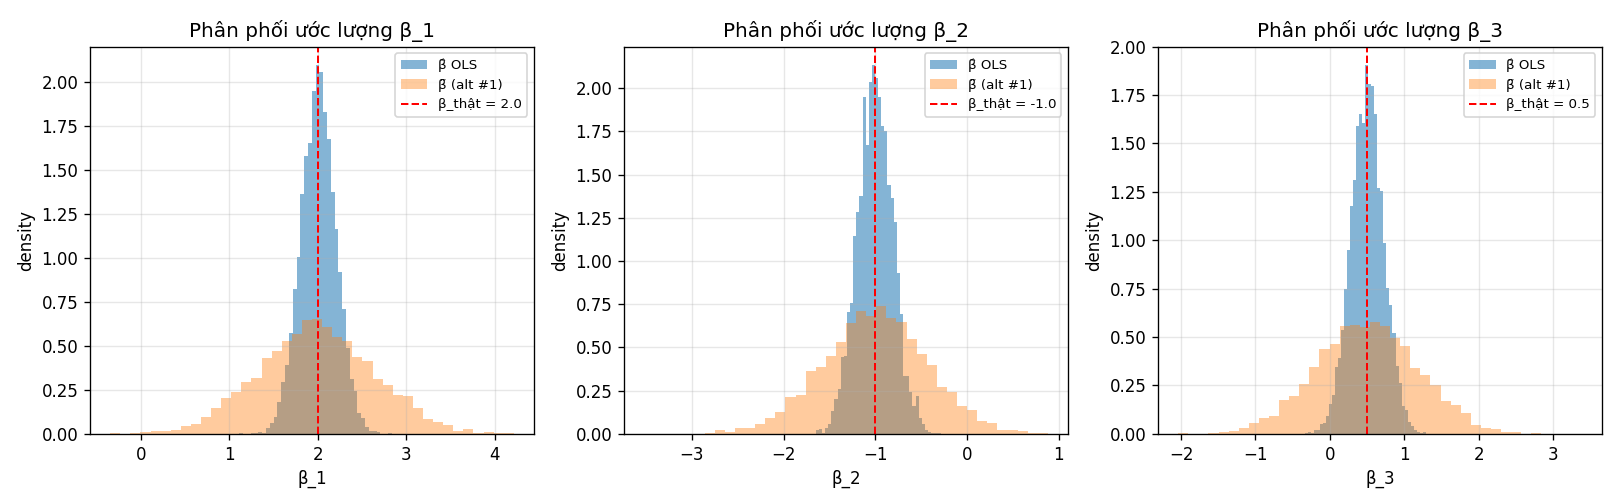


(d) KIỂM CHỨNG: OLS từ đầu so với sklearn.LinearRegression
mean(β̂_sklearn) - β  : [-0.0015885654121212678, -0.0017477096940843317, -0.0014661636364811104]
||Cov_emp - σ²(X^T X)^-1||_F = 1.6806e-03


In [10]:
import math
import random
from linalg_utils import (mat_sub, eye, )


# ============================================================
# Xây estimator thay thế: A = A_OLS + M(I - H), với M tùy ý
# ============================================================
def build_ols_matrix(X):
    """Trả về A_OLS = (X^T X)^{-1} X^T  (p × n)."""
    Xt = transpose(X)
    XtX_inv = inv(matmul(Xt, X))
    return matmul(XtX_inv, Xt), XtX_inv


def build_alt_estimator_matrix(X, M_random, A_ols):
    """
    Trả về A = A_OLS + M (I - H),  với H = X (X^T X)^{-1} X^T.
    Vì (I - H) X = 0, AX = A_OLS X = I  ⇒  β̃ unbiased.
    """
    n, p = shape(X)
    Xt = transpose(X)
    XtX_inv = inv(matmul(Xt, X))
    H = matmul(matmul(X, XtX_inv), Xt)        # n × n
    I_minus_H = mat_sub(eye(n), H)            # n × n
    M_IH = matmul(M_random, I_minus_H)        # p × n
    A_alt = [[A_ols[i][j] + M_IH[i][j] for j in range(n)] for i in range(p)]
    return A_alt


# ============================================================
# Thống kê trên list các vector
# ============================================================
def mean_vector(history):
    """history: list[ list[float] ] kích thước T × p."""
    T = len(history)
    p = len(history[0])
    return [sum(history[t][j] for t in range(T)) / T for j in range(p)]


def cov_matrix(history, ddof=0):
    """Hiệp phương sai từng cặp tọa độ qua T mẫu."""
    T = len(history)
    p = len(history[0])
    m = mean_vector(history)
    C = [[0.0] * p for _ in range(p)]
    for t in range(T):
        for i in range(p):
            di = history[t][i] - m[i]
            for j in range(p):
                C[i][j] += di * (history[t][j] - m[j])
    div = max(T - ddof, 1)
    for i in range(p):
        for j in range(p):
            C[i][j] /= div
    return C


def frob_norm(A):
    return math.sqrt(sum(a * a for row in A for a in row))


# ============================================================
# Mô phỏng Monte Carlo
# ============================================================
def gauss_markov_simulation(X, true_beta, sigma, n_trials, n_alt=3, seed=42):
    """
    Mô phỏng MC. Trả về dict các kết quả để in / vẽ.
    """
    rng = random.Random(seed)
    n, p = shape(X)

    # OLS estimator matrix + (X^T X)^{-1}
    A_ols, XtX_inv = build_ols_matrix(X)

    # Cov lý thuyết của OLS
    theo_cov = [[sigma * sigma * XtX_inv[i][j] for j in range(p)]
                for i in range(p)]

    # Tạo n_alt linear unbiased estimator khác OLS
    alt_matrices = []
    for k in range(n_alt):
        # Sinh M ngẫu nhiên với hệ số nhỏ để không "phá" quá đà
        scale = 0.05 + 0.03 * k          # mỗi estimator một mức nhiễu khác nhau
        M = [[scale * rng.gauss(0, 1) for _ in range(n)] for _ in range(p)]
        A_alt = build_alt_estimator_matrix(X, M, A_ols)
        alt_matrices.append(A_alt)

    # Tính sẵn Xβ
    Xbeta = matvec(X, true_beta)

    # Lưu lịch sử qua n_trials lần
    history_ols = []
    history_alt = [[] for _ in range(n_alt)]

    for _ in range(n_trials):
        eps = [rng.gauss(0, sigma) for _ in range(n)]
        y = [Xbeta[i] + eps[i] for i in range(n)]

        history_ols.append(matvec(A_ols, y))
        for k in range(n_alt):
            history_alt[k].append(matvec(alt_matrices[k], y))

    return {
        "true_beta":       true_beta,
        "sigma":           sigma,
        "n_trials":        n_trials,
        "ols_mean":        mean_vector(history_ols),
        "ols_cov_emp":     cov_matrix(history_ols),
        "ols_cov_theo":    theo_cov,
        "alt_means":       [mean_vector(h) for h in history_alt],
        "alt_covs":        [cov_matrix(h) for h in history_alt],
        "history_ols":     history_ols,
        "history_alt":     history_alt,
    }


# ============================================================
# (c) Dữ liệu giả lập
# ============================================================
def build_fixed_design(n=60, p=3, seed=1):
    rng = random.Random(seed)
    X = []
    for _ in range(n):
        row = [1.0] + [rng.gauss(0, 1) for _ in range(p - 1)]
        X.append(row)
    return X


# ============================================================
# In kết quả
# ============================================================
def print_results(res):
    p = len(res["true_beta"])

    print(f"\n{'='*64}")
    print(f"KIỂM CHỨNG (1):  E[β̂_OLS] ≈ β  (unbiased)")
    print(f"{'='*64}")
    print(f"β thật       : {[round(b, 4) for b in res['true_beta']]}")
    print(f"mean(β̂_OLS) : {[round(b, 4) for b in res['ols_mean']]}")
    diffs = [abs(res["ols_mean"][j] - res["true_beta"][j]) for j in range(p)]
    print(f"sai khác max : {max(diffs):.4e}   (giảm dần khi tăng n_trials)")

    print(f"\n{'='*64}")
    print(f"KIỂM CHỨNG (2):  Cov(β̂_OLS) ≈ σ² (X^T X)^{{-1}}")
    print(f"{'='*64}")
    print("Cov empirical:")
    for row in res["ols_cov_emp"]:
        print("  ", [round(v, 5) for v in row])
    print("Cov theoretical:")
    for row in res["ols_cov_theo"]:
        print("  ", [round(v, 5) for v in row])
    diff_mat = [[res["ols_cov_emp"][i][j] - res["ols_cov_theo"][i][j]
                 for j in range(p)] for i in range(p)]
    print(f"||Cov_emp - Cov_theo||_F = {frob_norm(diff_mat):.4e}")

    print(f"\n{'='*64}")
    print(f"KIỂM CHỨNG (3):  Var(β̃_j) ≥ Var(β̂_OLS_j)  (BLUE)")
    print(f"{'='*64}")
    ols_vars = [res["ols_cov_emp"][j][j] for j in range(p)]
    print(f"Var(β̂_OLS_j): {[round(v, 5) for v in ols_vars]}")
    n_alt = len(res["alt_means"])
    for k in range(n_alt):
        alt_vars = [res["alt_covs"][k][j][j] for j in range(p)]
        ratios = [alt_vars[j] / ols_vars[j] for j in range(p)]
        print(f"--- Estimator thay thế #{k+1} ---")
        print(f"  Var(β̃_j)      : {[round(v, 5) for v in alt_vars]}")
        print(f"  tỉ số / OLS    : {[round(r, 4) for r in ratios]}")
        if all(r >= 0.999 for r in ratios):     # cho phép sai số MC
            print(f"  ✓ Mọi tỉ số ≥ 1  →  phù hợp Gauss–Markov")
        else:
            print(f"  ⚠ Có tỉ số < 1 (sai số Monte Carlo, tăng n_trials sẽ hết)")


def plot_histograms(res, savepath="gauss_markov.png"):
    """Vẽ histogram β̂_OLS_j và β̃_j cho mỗi j."""
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("[Bỏ qua vẽ] matplotlib không có sẵn.")
        return

    p = len(res["true_beta"])
    fig, axes = plt.subplots(1, p, figsize=(4.5 * p, 4.2))
    if p == 1:
        axes = [axes]

    for j in range(p):
        ax = axes[j]
        ols_samples = [h[j] for h in res["history_ols"]]
        ax.hist(ols_samples, bins=40, alpha=0.55, label="β̂ OLS", density=True)
        # Chỉ vẽ alt #1 cho gọn
        if res["history_alt"]:
            alt_samples = [h[j] for h in res["history_alt"][0]]
            ax.hist(alt_samples, bins=40, alpha=0.4,
                    label="β̃ (alt #1)", density=True)
        ax.axvline(res["true_beta"][j], color="red", linestyle="--",
                   linewidth=1.2, label=f"β_thật = {res['true_beta'][j]}")
        ax.set_title(f"Phân phối ước lượng β_{j+1}")
        ax.set_xlabel(f"β_{j+1}")
        ax.set_ylabel("density")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(savepath, dpi=120)
    plt.close(fig)
    print(f"[OK] Đã lưu {savepath}")
    from IPython.display import Image
    display(Image(savepath))


# ============================================================
# (d) Kiểm chứng với numpy/sklearn
# ============================================================
def verify_with_numpy_sklearn(X, true_beta, sigma, n_trials=2000, seed=99):
    try:
        import numpy as np
        from sklearn.linear_model import LinearRegression
    except ImportError:
        print("[Bỏ qua kiểm chứng] numpy/sklearn không có sẵn.")
        return

    print(f"\n{'='*64}")
    print(f"(d) KIỂM CHỨNG: OLS từ đầu so với sklearn.LinearRegression")
    print(f"{'='*64}")
    rng = np.random.default_rng(seed)
    X_np = np.array(X)
    p = X_np.shape[1]
    true_beta_np = np.array(true_beta)
    Xbeta_np = X_np @ true_beta_np

    betas = np.zeros((n_trials, p))
    for t in range(n_trials):
        eps = rng.normal(0, sigma, size=X_np.shape[0])
        y = Xbeta_np + eps
        model = LinearRegression(fit_intercept=False).fit(X_np, y)
        betas[t] = model.coef_

    mean_emp = betas.mean(axis=0)
    cov_emp  = np.cov(betas.T, ddof=0)
    cov_theo = sigma * sigma * np.linalg.inv(X_np.T @ X_np)

    print(f"mean(β̂_sklearn) - β  : {(mean_emp - true_beta_np).tolist()}")
    print(f"||Cov_emp - σ²(X^T X)^-1||_F = "
          f"{np.linalg.norm(cov_emp - cov_theo):.4e}")


n, p = 60, 3
true_beta = [2.0, -1.0, 0.5]
sigma = 1.5
n_trials = 5000

X = build_fixed_design(n=n, p=p, seed=1)

res = gauss_markov_simulation(
    X=X,
    true_beta=true_beta,
    sigma=sigma,
    n_trials=n_trials,
    n_alt=3,
    seed=2024,
)

print_results(res)
plot_histograms(res)

verify_with_numpy_sklearn(X, true_beta, sigma, n_trials=3000, seed=99)